**Natural Language Processing Final Project**

**NLP-Sentiment Analysis with Amazon Kosmos Dataset**

**Introduction**

This Project is based on Sentiment Analysis Technique on Kosmos dataset from Kaggle. Sentiment Analysis helps in finding emotional tone of a sentence and helps businesses,researchers and developers understand opinions and sentiments expressed in text data which is important for applications like social media monitoring, customer feedback analysis and more(GeeksforGeeks,2025).

Cosmos is a company selling home textiles and daily wear related products through Amazon. It intends to increase its sells on products by analyzing comments/reviews it receives on Amazon. Positive reviews help in knowing what to continue doing to maintain sales. Negative reviews/complaints provides basis for improving the company/product features according to it. In this project,comments will be labelled by performing sentiment analysis and a classification model will be created from labelled data. Visualization will be done using bargraph and wordcloud.

**Data Explanation/Exploration**

Amazon Kosmos dataset is imported from Kaggle. It includes two main columns review and star where review is text form and star is in numerical form. To find most commonly used terms, after loading the dataset,the text was explored through Word Cloud and frequency barplots. Sentiment labels were generated automatically using VADER's compound score. VADER (Valence Aware Dictionary and sEntiment Reasoner) is a sentiment analysis tool designed for social media and informal text. It works well on short content like tweets, reviews, and comments that include slang, emojis, and abbreviations. It uses a predefined lexicon and rule-based approach to calculate sentiment scores.
Reviews scoring 0 were labelled positive and the rest were labelled negative. Grouping by sentiment label and averaging the star ratings confirmed the expected relationship: positive labels aligned with higher star ratings, validating the labeling approach.

**Algorithms or Techniques Analysis**

The review text was cleaned through different steps including converting to lowercase, removing punctuation and stopwords,filtering out rare words and lemmitizing each token. The preprocessed text was then represented as TF-IDF vectors. Two classifier were trained and evaluated: Logistic Regression, which serves as an interpretable baseline, and Random Forest, an ensemble method that handles non-linear patterns. Both were assessed using a 75/25 train-test split and 5-fold cross-validation for more reliable generalization estimates

*#Importing necessary libaries and loading the dataset*

In [ ]:
!pip install nltk
!pip install scikit-learn
!pip install pandas
!pip install numpy
!pip install pillow
!pip install textblob
!pip install wordcloud
!pip install scikit-surprise

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 4.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2554987 sha256=a3d4e39a1fc7601fe67d5d779b7a2e2cdb7bcba56025569d9d400d10355e28d7
  Stored in directory: /root/.cache/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from wordcloud import WordCloud
from nltk.corpus import stopwords
from textblob import Word, TextBlob
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from nltk.sentiment import SentimentIntensityAnalyzer
from warnings import filterwarnings

filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
pd.set_option('display.width', 400)

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vedatgul/kozmos")

print("Path to dataset files:", path)

100%|██████████| 304k/304k [00:00<00:00, 64.9MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/vedatgul/kozmos/versions/1


In [ ]:
import pandas as pd
import os

# 1. List files in the path to make sure you have the right filename
print(os.listdir(path))

# 2. Combine the path and the filename (assuming it's 'kozmos.csv')
file_path = os.path.join(path, "kozmos.csv")

# 3. Read the CSV
df = pd.read_csv(file_path)

['kozmos.csv']


In [ ]:
# Check data types, non-null counts, and memory usage
df.info()

# Load the first few rows
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5611 entries, 0 to 5610
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Star     5611 non-null   int64 
 1   HelpFul  5611 non-null   int64 
 2   Title    5559 non-null   object
 3   Review   5593 non-null   object
dtypes: int64(2), object(2)
memory usage: 175.5+ KB
   Star  HelpFul                                          Title                                             Review
0     5        0                                    looks great                                      Happy with it
1     5        0  Pattern did not align between the two panels.  Good quality material however the panels are m...
2     5        0               Imagery is stretched. Still fun.  Product was fun for bedroom windows.<br />Imag...
3     5        0                 Que se ven elegantes muy finas   Lo unico que me gustaria es que sean un poco ...
4     5        0                             

In [ ]:
df.shape

(5611, 4)

**Text Preprocessing**

Text preprocessing converts raw data into a clean,structured and standarized format,enabling effective feature extraction and improving model performance.Some applications of text preprocessing are machine translation,information retrieval,information extraction,sentimental analysis and question answering.Techniques text preprocessing involves tokenization,text removal,stemming,POS tagging and lemmatization(GeeksforGeeks, 2026).

The preprocessing began with converting all the text to lowercase, stripping punctuation,followed by removing common English word that carry little sentiment value.Rare words appearing in the bottom 1000 of the frequency distribution were also eliminated,as they are unlikely to generalize across the corpus. Lemmitization was also applied. It is more advanced form of text normalization compared to stemming.Instead of simply chopping off word endings,it considers the word's meaning and the part of speech to reduce it to base form or root form(lemma),ensuring the word retains its meaning(Kevinnjagi, 2024).It helped in reducing each word to its root form,ensuring that variations of the same word are treated as a single token.The result is a clean, normalized version of each review ready for feature extraction and modeling.

In [ ]:
# Convert Text to Lowercase and display first 10 rows
df['Review'] = df['Review'].str.lower()
df['Review'].head(10)

,Review
0,happy with it
1,good quality material however the panels are m...
2,product was fun for bedroom windows.<br />imag...
3,lo unico que me gustaria es que sean un poco ...
4,great bang for the buck i can't believe the qu...
5,looks different then photo
6,was exactly what i was looking for. heavy mate...
7,"looking at the picture, i thought these curtai..."
8,much whiter than i thought it would be and was...
9,these are curtains just as the picture shows. ...


In [ ]:
# Punctuations
#Cleaning the text by removing Punctuation and displaying first 10 rows
df['Review'] = df['Review'].str.replace(r'[^\w\s]', '', regex=True)
df['Review'].head(10)

,Review
0,happy with it
1,good quality material however the panels are m...
2,product was fun for bedroom windowsbr imagery ...
3,lo unico que me gustaria es que sean un poco ...
4,great bang for the buck i cant believe the qua...
5,looks different then photo
6,was exactly what i was looking for heavy mater...
7,looking at the picture i thought these curtain...
8,much whiter than i thought it would be and was...
9,these are curtains just as the picture shows t...


In [ ]:
# Stopwords
import nltk
#Downloads a predefined list of common English words (like the, is, and, in).
nltk.download('stopwords')
#Imports the stopwords list from the Natural Language Toolkit.
from nltk.corpus import stopwords
#Stores all English stopwords in a variable sw
sw = stopwords.words('english')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
#Takes each review,Converts it to a string,Splits it into words,Removes words that are in the stopwords list and Joins the remaining words back into a cleaned sentence

df['Review'] = df['Review'].apply(lambda x: " ".join(x for x in str(x).split() if x not in sw))

#Shows the first 10 cleaned reviews.

df['Review'].head(10)

,Review
0,happy
1,good quality material however panels mismatched
2,product fun bedroom windowsbr imagery bit stre...
3,lo unico que gustaria es que sean un poco mas ...
4,great bang buck cant believe quality material ...
5,looks different photo
6,exactly looking heavy material great price shi...
7,looking picture thought curtains would thinner...
8,much whiter thought would wasnt really expecti...
9,curtains picture shows 3rd set ambesonne curta...


In [ ]:
# Rarewords
# Join all reviews into a single string, split into words, and count frequency of each word
# Select the 1000 least frequent (rare) words from the vocabulary
del_ = pd.Series(' '.join(df['Review']).split()).value_counts()[-1000:]

# Remove rare words from each review, as they appear too infrequently
# For each review:Split into words,Keep only words NOT in the rare word list and join them back in the sentence

df['Review'] = df['Review'].apply(lambda x: " ".join(x for x in x.split() if x not in del_))

In [ ]:
# Lemmatization
# Download required NLTK resources — 'punkt' for tokenization, 'wordnet' as the lexical database
nltk.download('punkt')
nltk.download('wordnet')

# Apply lemmatization to each review — reduces each word to its base/root form
# e.g., "running" -> "run", "better" -> "good", ensuring different forms of the
# same word are treated as one, reducing vocabulary size and improving model generalization

df['Review'] = df['Review'].apply(lambda x: " ".join([Word(word).lemmatize() for word in x.split()]))

# Preview the first 10 cleaned and lemmatized reviews
df['Review'].head(10)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


,Review
0,happy
1,good quality material however panel mismatched
2,product fun bedroom windowsbr imagery bit stre...
3,lo unico que gustaria e que sean un poco ma la...
4,great bang buck cant believe quality material ...
5,look different photo
6,exactly looking heavy material great price shi...
7,looking picture thought curtain would thinner ...
8,much whiter thought would wasnt really expecti...
9,curtain picture show 3rd set ambesonne curtain...


**Data Visualization**

Data visualization uses graphs,charts and maps to present information clearly and simply. It turns complex data into visuals easy to understand.

In this project,Barplot and Word Cloud are used to visualize data. Barplot plots categorical data where length of each bar represents specific numeric value.It compares quantities across different groups and show changes over time. A word cloud is a collection of words from a text source,arranged in a visual cluster,often appearing in different sizes,colors and orientations.It provides a quick visual summary of most frequently used words or key themes in a text.


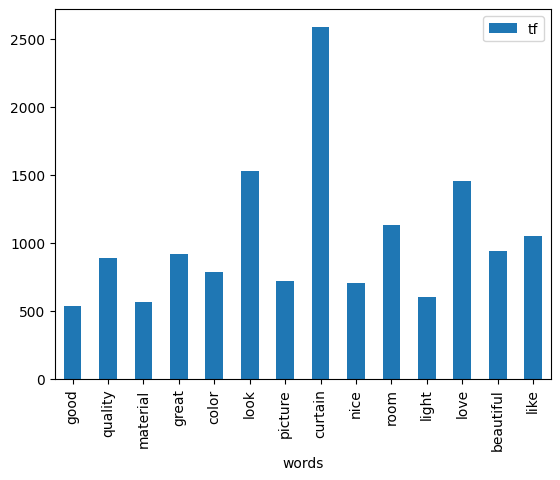

In [ ]:
# Barplot
# Word Frequency Bar Plot
# Split each review into words and count the frequency of each word per review,
# then sum counts across all reviews to get the total frequency of each word in the corpus

tf = df["Review"].apply(lambda x: pd.value_counts(x.split(" "))).sum(axis=0).reset_index()

# Rename columns for clarity — 'words' for the token and 'tf' for its total frequency count
tf.columns = ["words", "tf"]

# Filter to only words appearing more than 500 times to focus on the most
# significant terms, then plot as a bar chart to visualize dominant vocabulary
tf[tf["tf"] > 500].plot.bar(x="words", y="tf")
plt.show()

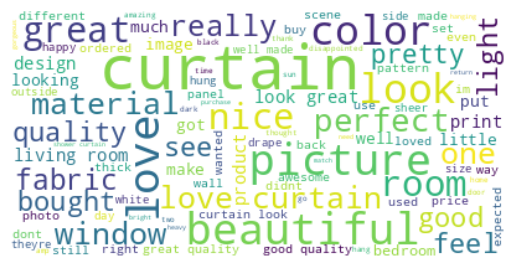

In [ ]:
# Wordcloud Visualization
# Concatenate all reviews into a single string to serve as input for the word cloud
text = " ".join(i for i in df.Review)

# Generate a word cloud with a max font size of 50, displaying the top 100 most  frequent words on a white background — larger words indicate higher frequency

wordcloud = WordCloud(max_font_size=50,
                      max_words=100,
                      background_color="white").generate(text)

 # Display the word cloud — axis is turned off for a cleaner visual presentation
plt.figure()
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

**Sentiment Analysis**

Sentiment analysis is the process of analyzing textual data to determine emotional tone expressed in it. It classifies text as positive,negative or neutral and can also detect more nuanced emotions like happy,sad,angry,or frustated(GeeksforGeeks, 2025). It enables businesses to monitor brand reputation, analyze customer feedback, and understand market trends in real-time by leveraging machine learning, deep learning, or rule-based approaches.

In [ ]:
# Download VADER lexicon — required for sentiment scoring of the reviews
nltk.download('vader_lexicon')


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [ ]:
  #Initialize the VADER Sentiment Intensity Analyzer to score each review

  sia = SentimentIntensityAnalyzer()

In [ ]:
# Get full polarity scores (positive, negative, neutral, compound) for the first 10 reviews
df["Review"][0:10].apply(lambda x: sia.polarity_scores(x))

# Extract only the compound score — a single normalized sentiment value between -1 and +1
df["Review"][0:10].apply(lambda x: sia.polarity_scores(x)["compound"])

# Convert compound score to binary label — 'pos' if above 0, otherwise 'neg'
df["Review"][0:10].apply(lambda x: "pos" if sia.polarity_scores(x)["compound"] > 0 else "neg")

# Apply the same binary labeling to the entire dataset and store as a new column
df["Sentiment_Label"] = df["Review"].apply(lambda x: "pos" if sia.polarity_scores(x)["compound"] > 0 else "neg")

# Validate labels by checking average star rating per sentiment group —
# 'pos' should have a higher mean star rating than 'neg'
df.groupby("Sentiment_Label")["Star"].mean()

,Star
Sentiment_Label,
neg,3.40
pos,4.58


**Modeling**

In [ ]:
# Test-Train
# Split data into 75% training and 25% test sets (default split ratio)
# Review text is the feature (X) and Sentiment_Label is the target (y)
# random_state=42 ensures reproducibility of the split
train_x, test_x, train_y, test_y = train_test_split(df["Review"],
                                                    df["Sentiment_Label"],
                                                    random_state=42)

In [ ]:
# TF-IDF Word Level Vectorization
# Fit the TF-IDF vectorizer on training data only to prevent data leakage
tf_idf_word_vectorizer = TfidfVectorizer().fit(train_x)

# Transform training and test reviews into TF-IDF feature matrices —
# each word is weighted by how unique it is across the corpus
x_train_tf_idf_word = tf_idf_word_vectorizer.transform(train_x)
x_test_tf_idf_word = tf_idf_word_vectorizer.transform(test_x)

In [ ]:
# Modelling(Logistic Regression)
# Train Logistic Regression model on TF-IDF features of the training set
log_model = LogisticRegression().fit(x_train_tf_idf_word, train_y)

# Generate predictions on the unseen test set
y_pred = log_model.predict(x_test_tf_idf_word)

#Print classification report showing precision, recall, F1-score
# and support for each sentiment class (pos/neg)
print(classification_report(y_pred, test_y))

              precision    recall  f1-score   support

         neg       0.32      0.91      0.48        79
         pos       0.99      0.89      0.94      1324

    accuracy                           0.89      1403
   macro avg       0.66      0.90      0.71      1403
weighted avg       0.96      0.89      0.91      1403



In [ ]:
# Cross Validation
# Evaluate the model using 5-fold cross-validation and average the scores
# to get a more reliable estimate of model performance than a single train-test split
cross_val_score(log_model, x_test_tf_idf_word, test_y, cv=5).mean()

np.float64(0.8538891713268937)

In [ ]:
# Randomly selecting comments from the data and asking them to the model
# Randomly sample one review from the dataset
random_review = pd.Series(df["Review"].sample(1).values)

# Vectorize the sampled review using CountVectorizer fitted on training data
new_comment = CountVectorizer().fit(train_x).transform(random_review)

# Predict the sentiment of the sampled review
pred = log_model.predict(new_comment)

# Print the review text alongside the model's predicted sentiment label
print(f'Review:  {random_review[0]} \n Prediction: {pred}')


Review:  love super cool think visibility door black curtain behind make easier see nice money 
 Prediction: ['pos']


In [ ]:
# Modelling (Random Forest)
# Train a Random Forest classifier on the same TF-IDF features for comparison
# against the Logistic Regression model
rf_model = RandomForestClassifier().fit(x_train_tf_idf_word, train_y)

# Train a Random Forest classifier on the same TF-IDF features for comparison
# against the Logistic Regression model
cross_val_score(rf_model, x_test_tf_idf_word, test_y, cv=5, n_jobs=-1).mean()

np.float64(0.8902338586680223)

**Conclusion**


Logistic regression worked well on TF-IDF features, showing that simple linear models can handle sentiment classification effectively with good preprocessing. Random forest was tested for comparison but didn't add much improvement.
The VADER labels aligned reasonably with star ratings, validating the approach — though collapsing sentiment into binary categories made it harder to handle mixed or neutral reviews. Future work could use BERT embeddings or treat star ratings directly as labels for more fine-grained predictions

**Refrences**

GeeksforGeeks. (2026, March 31). Text preprocessing for NLP tasks. https://www.geeksforgeeks.org/nlp/text-preprocessing-for-nlp-tasks/

Kevinnjagi (2024, October 17). Lemmatization in NLP. Medium. https://medium.com/@kevinnjagi83/lemmatization-in-nlp-2a61012c5d66

GeeksforGeeks. (2025, December 10). What is sentiment analysis? https://www.geeksforgeeks.org/machine-learning/what-is-sentiment-analysis/

GeeksforGeeks. (2025, July 11). Sentiment analysis using VADER - Using Python. GeeksforGeeks.

https://www.kaggle.com/datasets/vedatgul/kozmos

https://www.kaggle.com/code/vedatgul/nlp-sentiment-analysis-with-amazon-kosmos-dataset

